In [79]:
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import sys

In [80]:
OMV_FEATURE_INDEX = [5, 6]
INITIAL_FPS = '15'
RESAMPLE_RATE = 2
TARGET_ACCURACY = 0.8
SAFEGUARD = 1

PERIOD = ['Day', "Afternoon", "Night"]
BASE_PERIOD_INDEX = 0
VIDEO_PREFIX = 'Scene-1-'
# RP_PERIOD = 100
RP_AMOUNT = 4
CLASS_INDEX = '2'
NUM_SIG = 6

In [81]:
# Plot
plot_directory = 'short_result/plot_set'
power_profile_directory = 'short_result/Dict-Per-Real-Second-Throughput-960.json'

In [82]:
colors = [
	'#e6194B',
	# '#f58231',
	'#9A6324',
	'#911eb4',
	'#3cb44b',
	'#f032e6',
	'#4363d8',
]

In [83]:
def load_json_file(file_path):
	try:
		with open(file_path, 'r') as file:
			data = json.load(file)
		return data
	
	except Exception as e:
		print(f"An error occurred while loading the JSON file: {e}")
		return None

In [84]:
def extract_fpss(metric_list):
	return list(metric_list[list(metric_list.keys())[0]][0]['metric'].keys())

In [85]:
def to_accuracy_vector(accuracy_result_seq, fpss, type='F1'):
	accuracy_vector = []
	for fps in fpss:
		accuracy_vector.append(accuracy_result_seq[fps][type])
	
	return accuracy_vector

In [86]:
def plot_scatter(xs, ys, x_label, y_label, title, fig_size=(8, 8)):
	plt.figure(figsize=fig_size)
	plt.scatter(xs, ys, c=colors[0], s=30, alpha=0.5)
	plt.title(title)
	plt.xlabel(x_label)
	plt.ylabel(y_label)
	plt.show()

In [87]:
def plot_scatter_label(xs, ys, labels, x_label, y_label, title, fig_size=(8, 8)):
	plt.figure(figsize=fig_size)
	for i in range(len(xs)):
		plt.scatter(xs[i], ys[i], c=colors[labels[i]], s=30, alpha=0.5)
	plt.title(title)
	plt.xlabel(x_label)
	plt.ylabel(y_label)
	plt.show()

In [88]:
def filter_list_index(input_list, indices_to_remove):
	return [item for i, item in enumerate(input_list) if i not in indices_to_remove]

In [89]:
def round_float_to_sigfigs(number, sigfigs):
	return round(number, sigfigs)

## Plot

In [90]:
omv_features = ["Left-Top", "Right-Top", "Left-Bottom", "Right-Bottom", "Object-Amount", "Confidence", "IOU"]

In [91]:
plot_filenames = sorted(os.listdir(plot_directory))
plot_video_names = sorted(list(set([f.split('_')[0] for f in plot_filenames])))

In [92]:
fpss = extract_fpss(load_json_file(os.path.join(plot_directory, plot_video_names[0] + "_Accuracy_Result.json")))

In [93]:
omv_videos = []
acc_videos = []

for v in plot_video_names:
	omv_dict = {}
	for fps in fpss:
		omv_dict[fps] = []
	acc_list = []

	accuracy_result = load_json_file(os.path.join(plot_directory, v + "_Accuracy_Result.json"))
	movement_result = load_json_file(os.path.join(plot_directory, v + "_Movement_Result.json"))

	for class_idx in list(accuracy_result.keys()):
		for i in range(len(accuracy_result[class_idx])):
			accuracy_vector = to_accuracy_vector(accuracy_result[class_idx][i]['metric'], fpss)
			acc_list.append(accuracy_vector)

			for fps in fpss:
				movement_vector = movement_result[class_idx][i]['movement'][fps]
				omv_dict[fps].append(movement_vector)
	
	omv_videos.append(omv_dict)
	acc_videos.append(acc_list)

# Dataset

In [94]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures

In [95]:
def transpose_array(arr):
	# Transpose the input array using zip and map it back to a list
	return [list(row) for row in zip(*arr)]

In [96]:
def my_train_test_split(x, y, test_size):
	split_point = int(len(x) * (1-test_size))
	return x[0:split_point], x[split_point:len(x)], y[0:split_point], y[split_point:len(x)]

In [97]:
def root_mean_squared_error(y_train, y_train_pred):
	return np.sqrt(mean_squared_error(y_train, y_train_pred))

In [98]:
# Dataset Build

dataset = {}

for i in range(len(plot_video_names)):
	video_name = plot_video_names[i]
	dataset[video_name] = {}
	
	for k in range(len(fpss)):
		fps = fpss[k]
		dataset[video_name][fps] = {}
		y_all = None
		x_all_t = []

		for j in range(len(omv_videos[0][fpss[0]][0])):	
			fps = fpss[k]

			omv_fps = list(np.array(omv_videos[i][fps])[:, j])
			acc_fps = list(np.array(acc_videos[i])[:, k])

			# Remove Outliers
			# outlier_index = [l for l in range(len(omv_fps)) if omv_fps[l] == -1]
			# omv_fps_clean = filter_list_index(omv_fps, outlier_index)
			# acc_fps_clean = filter_list_index(acc_fps, outlier_index)

			if j == 0:
				y_all = acc_fps.copy()
			if j in OMV_FEATURE_INDEX:
				x_all_t.append(omv_fps.copy())
		
		x_all = transpose_array(x_all_t)
		dataset[video_name][fps]['y_all'] = y_all
		dataset[video_name][fps]['x_all'] = x_all
			

In [99]:
def my_train_test_split(x, y, test_size):
	split_point = int(len(x) * (1-test_size))
	return x[0:split_point], x[split_point:len(x)], y[0:split_point], y[split_point:len(x)]

# Train and Test

In [100]:
def estimate_best_fps_v1(prediction_models, clip_omv_of_fps, fpss, target_accuracy, safeguard):
	accuracy_vector = [prediction_models[fps].predict([clip_omv_of_fps])[0] for fps in fpss]

	for i in range(len(fpss)):
		if accuracy_vector[i] >= target_accuracy:
			return fpss[min(i + safeguard, len(fpss)-1)]

	return fpss[-1]

In [101]:
def estimate_best_fps_v2(prediction_models, clip_omv_of_fps, fpss, target_accuracy, safeguard):
	accuracy_vector = [prediction_models[fps].predict([clip_omv_of_fps])[0] for fps in fpss]

	min_idx = 0
	for i in range(len(fpss)):
		if abs(accuracy_vector[i] - target_accuracy) < abs(accuracy_vector[min_idx] - target_accuracy):
			min_idx = i

	return fpss[min(min_idx + safeguard, len(fpss) - 1)]

In [102]:
def estimate_best_fps_v3(prediction_models, clip_omv_of_fps, fpss, target_accuracy, safeguard, last_fps):
	accuracy_vector = [prediction_models[fps].predict([clip_omv_of_fps])[0] for fps in fpss]

	min_idx = 0
	for i in range(len(fpss)):
		if abs(accuracy_vector[i] - target_accuracy) < abs(accuracy_vector[min_idx] - target_accuracy):
			min_idx = i
	
	corrected_min_idx = min_idx + safeguard
	if corrected_min_idx >= len(fpss) - 1:
		if last_fps == len(fpss) - 2:
			corrected_min_idx = len(fpss) - 1
		else:
			corrected_min_idx = len(fpss) - 2

	return fpss[corrected_min_idx]

In [103]:
def extract_metric_list(metric_list, fpss, feature='F1'):
	result_column = {}
	
	for fps in fpss: 
		result_column[fps] = [clip_metric['metric'][fps][feature] for clip_metric in metric_list]
	
	return result_column

In [104]:
def find_max_index(string_list):
	# Convert each element to integer
	int_list = [int(element) for element in string_list]
	
	# Find index of maximum integer value
	max_index, max_value = max(enumerate(int_list), key=lambda x: x[1])
	
	return max_value

def extract_cheapest_fps(accuracy_dict, fpss, threshold=0.75):
	max_fps = find_max_index(fpss)
	
	cheapest_fpss = []
	for i in range(len(accuracy_dict[fpss[0]])):
		curr_fps = max_fps
		for fps in fpss:
			if accuracy_dict[fps][i] >= threshold and int(fps) < int(curr_fps):
				curr_fps = fps
		
		cheapest_fpss.append(int(curr_fps))
	
	return cheapest_fpss

In [105]:
def extract_nearest_fps(accuracy_dict, fpss, threshold=0.75):
	nearest_fpss = []
	for i in range(len(accuracy_dict[fpss[0]])):
		curr_fps = fpss[0]
		for fps in fpss:
			if abs(accuracy_dict[fps][i] - threshold) < abs(accuracy_dict[curr_fps][i] - threshold):
				curr_fps = fps
		
		nearest_fpss.append(int(curr_fps))
	
	return nearest_fpss

In [106]:
def plot_mutiple_lines(xs, yss, x_label, y_label, y_legends, title, fig_size, label_size=28, font_size=32, legend_size=20):
	fig, ax1 = plt.subplots(figsize=fig_size)

	for i in range(len(yss)):
		ax1.plot(xs, yss[i], color=colors[i], label=y_legends[i])

	ax1.set_xlabel(x_label, fontsize=font_size)
	ax1.set_ylabel(y_label, fontsize=font_size)
	# ax1.set_title(title, fontsize=font_size)
	plt.xticks(fontsize=label_size)
	plt.yticks(fontsize=label_size)
	plt.legend(fontsize=legend_size)
	plt.grid(True)

	plt.show()

In [107]:
def plot_mutiple_lines_horizontal(xs, yss, x_axis, y_axis, y_label_prefix, y_labels, title, label_size=28, font_size=32, legend_size=16, line_width=3):
	fig, ax1 = plt.subplots(figsize=(9, 6))
	
	for i in range(len(yss)):
		ax1.plot(xs, yss[i], color=colors[i], marker='o', label=f'{y_label_prefix}{y_labels[i]}')

	ax1.set_xlabel(x_axis, fontsize=font_size)
	ax1.set_ylabel(y_axis, fontsize=font_size)
	ax1.set_title(title, fontsize=font_size)
	plt.xticks(fontsize=label_size)
	plt.yticks(fontsize=label_size)
	plt.legend(fontsize=legend_size)
	plt.grid(True)

	plt.show()

In [108]:
period_result = {}
period_result[VIDEO_PREFIX] = {}
period_result[VIDEO_PREFIX][TARGET_ACCURACY] = {}
period_result[VIDEO_PREFIX][TARGET_ACCURACY]['non_rp'] = {}

## Non Re-profiling

In [109]:
def generate_train_index_sets(data_length, rp_period, rp_amount):
	train_sets = []
	curr_index = 0
	while curr_index < data_length:
		train_sets.append(list(range(curr_index, curr_index + rp_amount)))
		curr_index += rp_period
	
	return train_sets

In [110]:
nrp_baseline_accuracy = []
nrp_eva_accuracy = []
nrp_baseline_power = []
nrp_eva_power = []
for p in range(len(PERIOD)):
	print(f'Period: {PERIOD[p]}')
	period_video_name = f'{VIDEO_PREFIX}{PERIOD[p]}'

	# Test
	test_length = len(dataset[period_video_name]['30']['x_all'])
	train_index_list = generate_train_index_sets(test_length, sys.maxsize, RP_AMOUNT)

	accuracy_result = load_json_file(os.path.join(plot_directory, period_video_name + "_Accuracy_Result.json"))
	accuracy = extract_metric_list(accuracy_result[CLASS_INDEX], fpss)
	nearest_fps_list = extract_nearest_fps(accuracy, fpss, TARGET_ACCURACY)

	selected_fps_list_for_accuracy = []
	selected_fps_list_for_power = []
	last_fps = INITIAL_FPS
	train_index_list_idx = 0
	for i in range(test_length):
		if train_index_list_idx < len(train_index_list) and i == train_index_list[train_index_list_idx][0]:
			# Train
			prediction_models = {}
			for fps in fpss:
				prediction_models[fps] = LinearRegression()

			for fps in fpss:
				x_all = dataset[period_video_name][fps]['x_all']
				y_all = dataset[period_video_name][fps]['y_all']

				train_start_idx = train_index_list[train_index_list_idx][0]
				train_end_idx = train_index_list[train_index_list_idx][-1]

				x_train = x_all[train_start_idx : train_end_idx]
				y_train = y_all[train_start_idx : train_end_idx]
						
				prediction_models[fps].fit(x_train, y_train)

		if train_index_list_idx < len(train_index_list) and i in train_index_list[train_index_list_idx]:
			ground_truth_fps = str(nearest_fps_list[i])
			selected_fps_list_for_accuracy.append(ground_truth_fps)
			selected_fps_list_for_power.append(fpss[-1])
			last_fps = ground_truth_fps
			
			if i == train_index_list[train_index_list_idx][-1]:
				train_index_list_idx += 1
			
			continue

		if i % RESAMPLE_RATE != 0:
			selected_fps_list_for_accuracy.append(last_fps)
			selected_fps_list_for_power.append(last_fps)
			continue

		clip_omv_of_fps = dataset[period_video_name][last_fps]['x_all'][i]
		suggested_fps = estimate_best_fps_v3(prediction_models, clip_omv_of_fps, fpss, TARGET_ACCURACY, SAFEGUARD, last_fps)

		last_fps = suggested_fps
		selected_fps_list_for_accuracy.append(last_fps)
		selected_fps_list_for_power.append(last_fps)

	selected_fps_list_for_accuracy = [int(x) for x in selected_fps_list_for_accuracy]
	selected_fps_list_for_power = [int(x) for x in selected_fps_list_for_power]

	selected_accuracy_list = []
	for i in range(test_length):
		selected_throughput = str(selected_fps_list_for_accuracy[i])
		selected_accuracy = accuracy_result[CLASS_INDEX][i]['metric'][selected_throughput]['F1']
		selected_accuracy_list.append(selected_accuracy)
	
	nearest_accuracy_list = []
	for i in range(test_length):
		nearest_throughput = str(nearest_fps_list[i])
		nearest_accuracy = accuracy_result[CLASS_INDEX][i]['metric'][nearest_throughput]['F1']
		nearest_accuracy_list.append(nearest_accuracy)

	power_profile = load_json_file(os.path.join(power_profile_directory))
	max_power = power_profile[str(max([int(k) for k in list(power_profile.keys())]))]

	selected_power_list = []
	for st in selected_fps_list_for_power:
		if str(st) in power_profile:
			selected_power_list.append(power_profile[str(st)])
		else:
			selected_power_list.append(max_power)

	nearest_power_list = []
	for nt in nearest_fps_list:
		if str(nt) in power_profile:
			nearest_power_list.append(power_profile[str(nt)])
		else:
			nearest_power_list.append(max_power)
	
	time = range(test_length)
	print(f'Selected F1 Accuracy: {round(np.mean(np.array(selected_accuracy_list)), NUM_SIG)}')
	print(f'Nearest F1 Accuracy: {round(np.mean(np.array(nearest_accuracy_list)), NUM_SIG)}')
	print(f'Selected Power: {round(np.mean(np.array(selected_power_list)), NUM_SIG)}')
	print(f'Nearest Power: {round(np.mean(np.array(nearest_power_list)), NUM_SIG)}')

	nrp_eva_accuracy.append(round(np.mean(np.array(selected_accuracy_list)), NUM_SIG))
	nrp_baseline_accuracy.append(round(np.mean(np.array(nearest_accuracy_list)), NUM_SIG))
	nrp_eva_power.append(round(np.mean(np.array(selected_power_list)), NUM_SIG))
	nrp_baseline_power.append(round(np.mean(np.array(nearest_power_list)), NUM_SIG))

	# plot_mutiple_lines(time, [selected_fps_list_for_power, nearest_fps_list], 'Time', 'FPS', ['Selected', 'Optimal'], '', (24, 6))
	# plot_mutiple_lines(time, [selected_accuracy_list, nearest_accuracy_list], 'Time', 'Accuracy', ['Selected Accuracy', 'Nearest Accuracy'], '', (36, 6))
	# plot_mutiple_lines(time, [selected_power_list, nearest_power_list], 'Time', 'Power', ['Selected Power', 'Nearest Power'], '', (36, 6))

	print("")

period_result[VIDEO_PREFIX][TARGET_ACCURACY]['non_rp']['baseline_accuracy'] = nrp_baseline_accuracy
period_result[VIDEO_PREFIX][TARGET_ACCURACY]['non_rp']['eva_accuracy'] = nrp_eva_accuracy
period_result[VIDEO_PREFIX][TARGET_ACCURACY]['non_rp']['baseline_power'] = nrp_baseline_power
period_result[VIDEO_PREFIX][TARGET_ACCURACY]['non_rp']['eva_power'] = nrp_eva_power

Period: Day
Selected F1 Accuracy: 0.900938
Nearest F1 Accuracy: 0.817255
Selected Power: 4.388927
Nearest Power: 3.527889

Period: Afternoon
Selected F1 Accuracy: 0.817901
Nearest F1 Accuracy: 0.833542
Selected Power: 3.897361
Nearest Power: 3.623025

Period: Night
Selected F1 Accuracy: 0.854134
Nearest F1 Accuracy: 0.808664
Selected Power: 4.852169
Nearest Power: 3.976058



## Re-profiling

In [111]:
rp_result = {}
rp_result[VIDEO_PREFIX] = {}
rp_result[VIDEO_PREFIX][TARGET_ACCURACY] = {}
rp_result[VIDEO_PREFIX][TARGET_ACCURACY]['rp'] = {}

rp_result[VIDEO_PREFIX][TARGET_ACCURACY]['rp']['eva_accuracy_list'] = []
rp_result[VIDEO_PREFIX][TARGET_ACCURACY]['rp']['eva_power_list'] = []

In [112]:
test_length = len(dataset[f'{VIDEO_PREFIX}{PERIOD[0]}']['30']['x_all'])

for i in range(RP_AMOUNT, test_length-RP_AMOUNT+1):
	train_index_list = [list(range(i, i+RP_AMOUNT))]
	print(f'Current Start Index: {i}')
	
	# Old code
	rp_eva_accuracy = []
	rp_eva_power = []
	for p in range(len(PERIOD)):
		print(f'Period: {PERIOD[p]}')
		period_video_name = f'{VIDEO_PREFIX}{PERIOD[p]}'

		# Test
		test_length = len(dataset[period_video_name]['30']['x_all'])

		accuracy_result = load_json_file(os.path.join(plot_directory, period_video_name + "_Accuracy_Result.json"))
		accuracy = extract_metric_list(accuracy_result[CLASS_INDEX], fpss)
		nearest_fps_list = extract_nearest_fps(accuracy, fpss, TARGET_ACCURACY)

		selected_fps_list_for_accuracy = []
		selected_fps_list_for_power = []
		last_fps = INITIAL_FPS
		train_index_list_idx = 0
		for i in range(test_length):
			if train_index_list_idx < len(train_index_list) and i == train_index_list[train_index_list_idx][0]:
				# Train
				prediction_models = {}
				for fps in fpss:
					prediction_models[fps] = LinearRegression()

				for fps in fpss:
					x_all = dataset[period_video_name][fps]['x_all']
					y_all = dataset[period_video_name][fps]['y_all']

					train_start_idx = train_index_list[train_index_list_idx][0]
					train_end_idx = train_index_list[train_index_list_idx][-1]

					x_train = x_all[train_start_idx : train_end_idx]
					y_train = y_all[train_start_idx : train_end_idx]
							
					prediction_models[fps].fit(x_train, y_train)

			if train_index_list_idx < len(train_index_list) and i in train_index_list[train_index_list_idx]:
				ground_truth_fps = str(nearest_fps_list[i])
				selected_fps_list_for_accuracy.append(ground_truth_fps)
				selected_fps_list_for_power.append(fpss[-1])
				last_fps = ground_truth_fps
				
				if i == train_index_list[train_index_list_idx][-1]:
					train_index_list_idx += 1
				
				continue

			if i % RESAMPLE_RATE != 0:
				selected_fps_list_for_accuracy.append(last_fps)
				selected_fps_list_for_power.append(last_fps)
				continue

			clip_omv_of_fps = dataset[period_video_name][last_fps]['x_all'][i]
			suggested_fps = estimate_best_fps_v3(prediction_models, clip_omv_of_fps, fpss, TARGET_ACCURACY, SAFEGUARD, last_fps)

			last_fps = suggested_fps
			selected_fps_list_for_accuracy.append(last_fps)
			selected_fps_list_for_power.append(last_fps)

		selected_fps_list_for_accuracy = [int(x) for x in selected_fps_list_for_accuracy]
		selected_fps_list_for_power = [int(x) for x in selected_fps_list_for_power]

		selected_accuracy_list = []
		for i in range(test_length):
			selected_throughput = str(selected_fps_list_for_accuracy[i])
			selected_accuracy = accuracy_result[CLASS_INDEX][i]['metric'][selected_throughput]['F1']
			selected_accuracy_list.append(selected_accuracy)
		
		nearest_accuracy_list = []
		for i in range(test_length):
			nearest_throughput = str(nearest_fps_list[i])
			nearest_accuracy = accuracy_result[CLASS_INDEX][i]['metric'][nearest_throughput]['F1']
			nearest_accuracy_list.append(nearest_accuracy)

		power_profile = load_json_file(os.path.join(power_profile_directory))
		max_power = power_profile[str(max([int(k) for k in list(power_profile.keys())]))]

		selected_power_list = []
		for st in selected_fps_list_for_power:
			if str(st) in power_profile:
				selected_power_list.append(power_profile[str(st)])
			else:
				selected_power_list.append(max_power)

		nearest_power_list = []
		for nt in nearest_fps_list:
			if str(nt) in power_profile:
				nearest_power_list.append(power_profile[str(nt)])
			else:
				nearest_power_list.append(max_power)
		
		time = range(test_length)
		print(f'Selected F1 Accuracy: {round(np.mean(np.array(selected_accuracy_list)), NUM_SIG)}')
		print(f'Nearest F1 Accuracy: {round(np.mean(np.array(nearest_accuracy_list)), NUM_SIG)}')
		print(f'Selected Power: {round(np.mean(np.array(selected_power_list)), NUM_SIG)}')
		print(f'Nearest Power: {round(np.mean(np.array(nearest_power_list)), NUM_SIG)}')

		rp_eva_accuracy.append(round(np.mean(np.array(selected_accuracy_list)), NUM_SIG))
		rp_eva_power.append(round(np.mean(np.array(selected_power_list)), NUM_SIG))

		# plot_mutiple_lines(time, [selected_fps_list_for_power, nearest_fps_list], 'Time', 'FPS', ['Selected', 'Optimal'], '', (24, 6))
		# plot_mutiple_lines(time, [selected_accuracy_list, nearest_accuracy_list], 'Time', 'Accuracy', ['Selected Accuracy', 'Nearest Accuracy'], '', (36, 6))
		# plot_mutiple_lines(time, [selected_power_list, nearest_power_list], 'Time', 'Power', ['Selected Power', 'Nearest Power'], '', (36, 6))

		print("")

	rp_result[VIDEO_PREFIX][TARGET_ACCURACY]['rp']['eva_accuracy_list'].append(rp_eva_accuracy)
	rp_result[VIDEO_PREFIX][TARGET_ACCURACY]['rp']['eva_power_list'].append(rp_eva_power)

Current Start Index: 4
Period: Day
Selected F1 Accuracy: 0.85287
Nearest F1 Accuracy: 0.817255
Selected Power: 3.793375
Nearest Power: 3.527889

Period: Afternoon
Selected F1 Accuracy: 0.898218
Nearest F1 Accuracy: 0.833542
Selected Power: 4.607487
Nearest Power: 3.623025

Period: Night
Selected F1 Accuracy: 0.805691
Nearest F1 Accuracy: 0.808664
Selected Power: 4.712877
Nearest Power: 3.976058

Current Start Index: 5
Period: Day
Selected F1 Accuracy: 0.822006
Nearest F1 Accuracy: 0.817255
Selected Power: 3.873936
Nearest Power: 3.527889

Period: Afternoon
Selected F1 Accuracy: 0.802059
Nearest F1 Accuracy: 0.833542
Selected Power: 3.871108
Nearest Power: 3.623025

Period: Night
Selected F1 Accuracy: 0.8721
Nearest F1 Accuracy: 0.808664
Selected Power: 5.085653
Nearest Power: 3.976058

Current Start Index: 6
Period: Day
Selected F1 Accuracy: 0.864377
Nearest F1 Accuracy: 0.817255
Selected Power: 4.205822
Nearest Power: 3.527889

Period: Afternoon
Selected F1 Accuracy: 0.807478
Nearest 

In [113]:
def transpose_2d_list(matrix):
	"""
	Transpose a 2D list (matrix).

	Args:
			matrix (list of lists): The 2D list to transpose.

	Returns:
			list of lists: The transposed 2D list.
	"""
	# Use zip with unpacking to transpose the matrix
	return [list(row) for row in zip(*matrix)]

In [114]:
def plot_two_ys(xs, y1s, y2s, x_label, y1_label, y2_label, title, label_size=28, font_size=32):
	fig, ax1 = plt.subplots(figsize=(36, 9))

	ax1.plot(xs, y1s, color=colors[0], marker='o', label=y1_label)  # 'o' denotes the marker type
	ax1.set_xlabel(x_label, fontsize=font_size)
	ax1.set_ylabel(y1_label, color=colors[0], fontsize=font_size)
	ax1.tick_params(axis='both', labelsize=label_size)

	ax2 = ax1.twinx()
	ax2.plot(xs, y2s, color=colors[3], marker='o', label=y2_label)  # 'o' denotes the marker type
	ax2.set_ylabel(y2_label, color=colors[3], fontsize=font_size)
	ax2.tick_params(axis='y', labelsize=label_size)

	plt.title(title, fontsize=font_size)
	plt.grid(True)

	plt.show()

In [115]:
def plot_two_ys_horizontal_line(xs, y1s, y2s, x_label, y1_label, y2_label, title, horizontal_line=None, label_size=28, font_size=32):
	fig, ax1 = plt.subplots(figsize=(36, 9))

	ax1.plot(xs, y1s, color=colors[0], marker='o', label=y1_label, linewidth=2)  # 'o' denotes the marker type
	ax1.set_xlabel(x_label, fontsize=font_size)
	ax1.set_ylabel(y1_label, color=colors[0], fontsize=font_size)
	ax1.tick_params(axis='both', labelsize=label_size)
	ax1.set_xlim([0, 180])

	ax2 = ax1.twinx()
	ax2.plot(xs, y2s, color=colors[3], marker='o', label=y2_label, linewidth=2)  # 'o' denotes the marker type
	ax2.set_ylabel(y2_label, color=colors[3], fontsize=font_size)
	ax2.tick_params(axis='y', labelsize=label_size)
	ax2.set_xlim([0, 180])

	if horizontal_line is not None:
		ax1.axhline(y=horizontal_line, color=colors[4], linewidth=4)

	plt.title(title, fontsize=font_size)
	plt.grid(True)

	plt.show()

In [116]:
plot_non_rp_result = period_result[VIDEO_PREFIX][TARGET_ACCURACY]['non_rp']
plot_rp_result = rp_result[VIDEO_PREFIX][TARGET_ACCURACY]['rp']

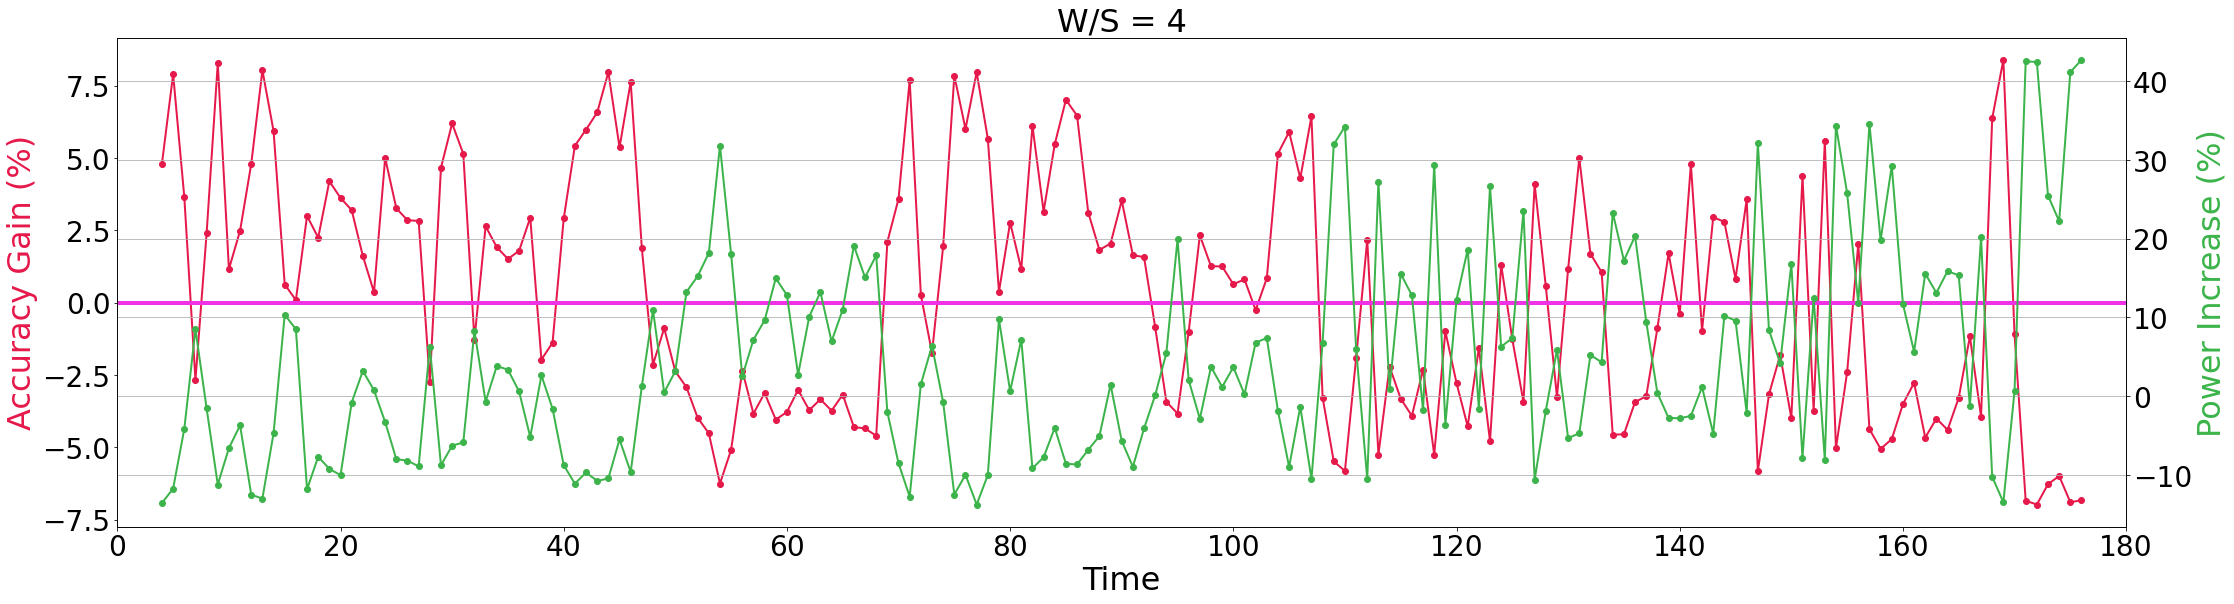

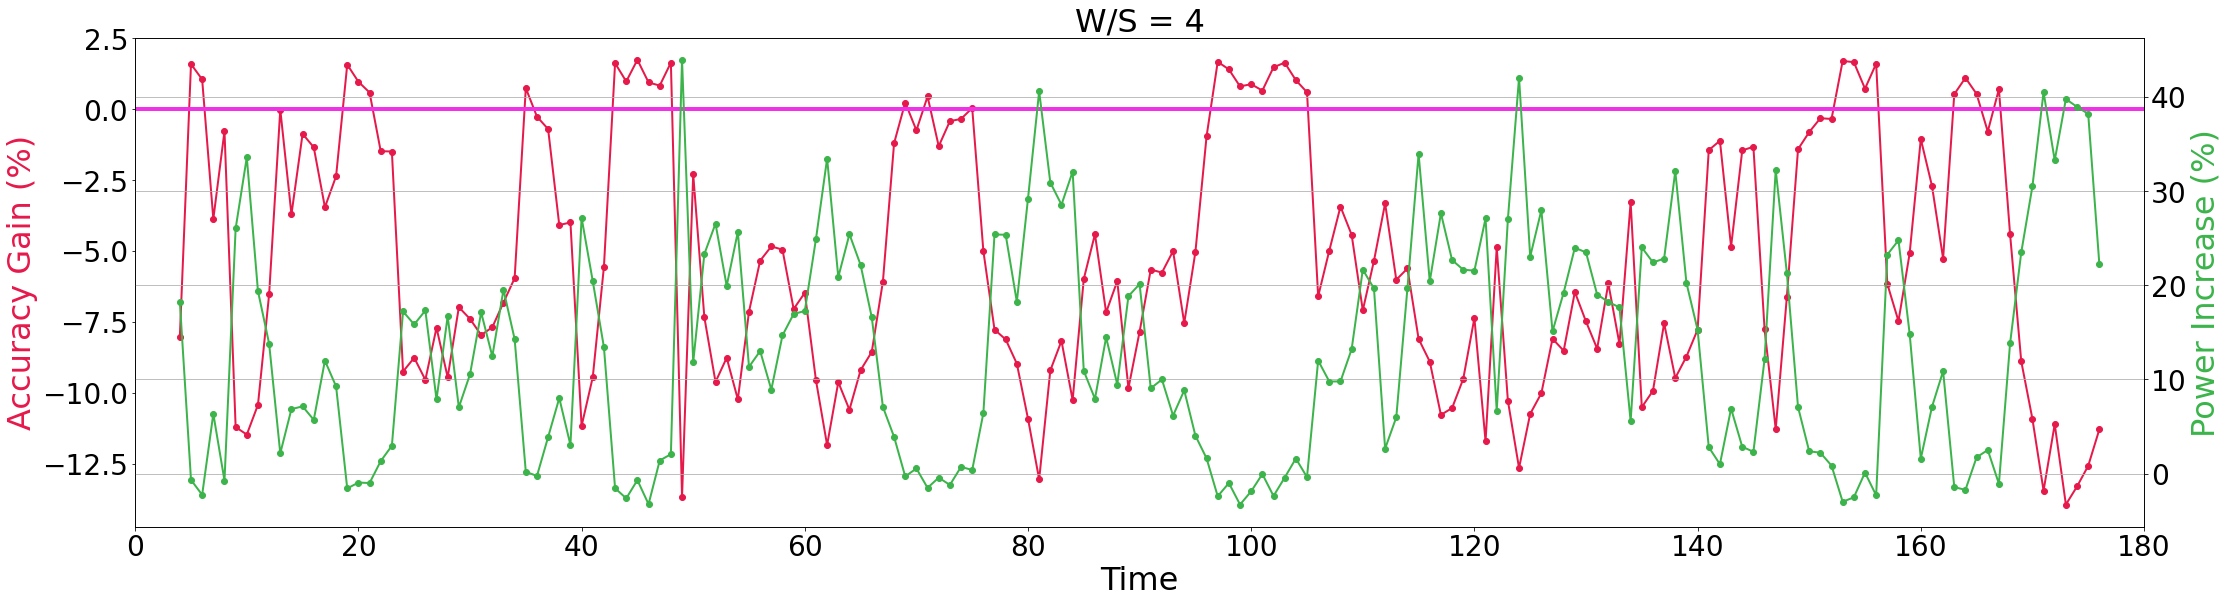

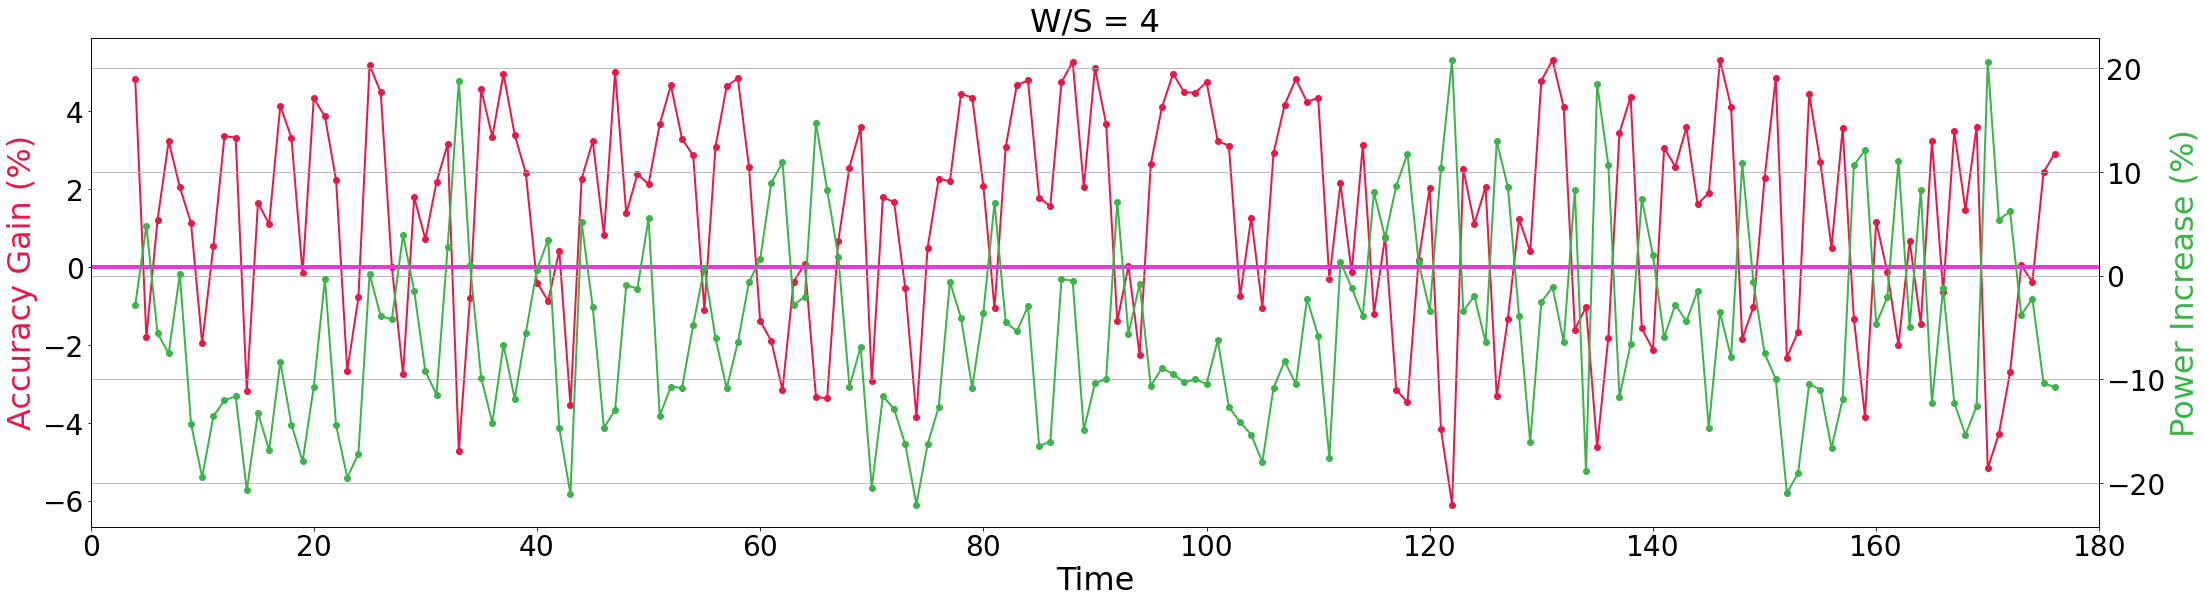

In [117]:
eva_accuracy_list = plot_rp_result['eva_accuracy_list']
eva_power_list = plot_rp_result['eva_power_list']

for i in range(len(PERIOD)):
	p_accuracy_list = [l[i] for l in eva_accuracy_list]
	p_accuracy_base = plot_non_rp_result['eva_accuracy'][i]
	p_accuracy_change = [(abs(p_accuracy_base - TARGET_ACCURACY) - abs(p_accuracy_v - TARGET_ACCURACY)) for p_accuracy_v in p_accuracy_list]

	p_power_list = [l[i] for l in eva_power_list]
	p_power_base = plot_non_rp_result['eva_power'][i]
	p_power_change = [(p_power_v / p_power_base) for p_power_v in p_power_list]

	time = list(range(RP_AMOUNT, test_length-RP_AMOUNT+1))
	plot_two_ys_horizontal_line(time, list(np.array(p_accuracy_change) * 100), list(np.array(p_power_change) * 100 - 100), 'Time', 'Accuracy Gain (%)', 'Power Increase (%)', f'W/S = {RP_AMOUNT}', 0)